In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
from utils import DATA_DIR
import logging
logging.basicConfig(level=logging.INFO)
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from arch import arch_model
import numpy as np
import pandas as pd
from modern_backtrader.data_feeds import DataFeeds
from modern_backtrader.state_manager import StateManager
from modern_backtrader.broker import Broker
import tushare as ts
from joblib import Parallel, delayed

load_dotenv()
DATA_DIR.mkdir(parents=True, exist_ok=True)

Text(0, 0.5, 'Cum Return')

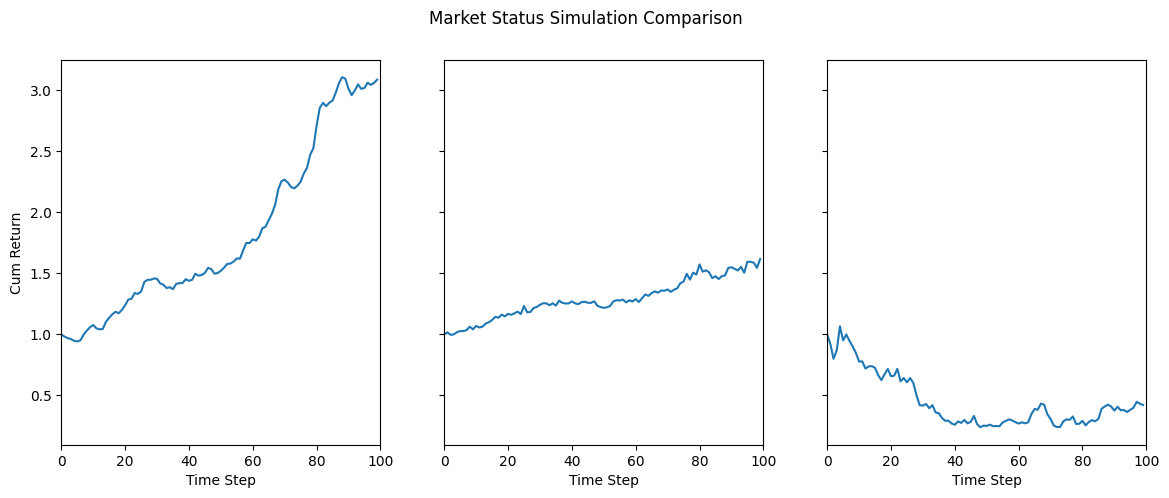

In [2]:
def create_ar1_generator(mu, rho, n_periods=100):
    np.random.seed(42)
    def generate(sigma_callback=lambda i : 0.02):
        rtn = np.random.randn(n_periods)
        rtn[0] = mu / (1 - rho)

        for i in range(1, n_periods):
            epsilon = np.random.normal(0, sigma_callback(i))
            rtn[i] = mu + rho * rtn[i - 1] + epsilon
        prices = np.exp(np.cumsum(rtn))
        prices = prices / prices[0]
        return rtn, prices
    return generate

generator_1 = create_ar1_generator(0.005, 0.5)
generator_2 = create_ar1_generator(0.005, -0.5)
generator_3 = create_ar1_generator(0.005, 0.1)

_, prices_1 = generator_1()
_, prices_2 = generator_2()
_, prices_3 = generator_3(sigma_callback=lambda i: 0.1)
prices_lst = [prices_1, prices_2, prices_3]

fig1, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, sharex=True)
fig1.suptitle('Market Status Simulation Comparison')
for i in range(3):
    axes[i].plot(prices_lst[i])
    axes[i].set_xlabel('Time Step')
    axes[i].set_xlim([0, 100])
axes[0].set_ylabel('Cum Return')

Text(0.5, 0, 'Time Step')

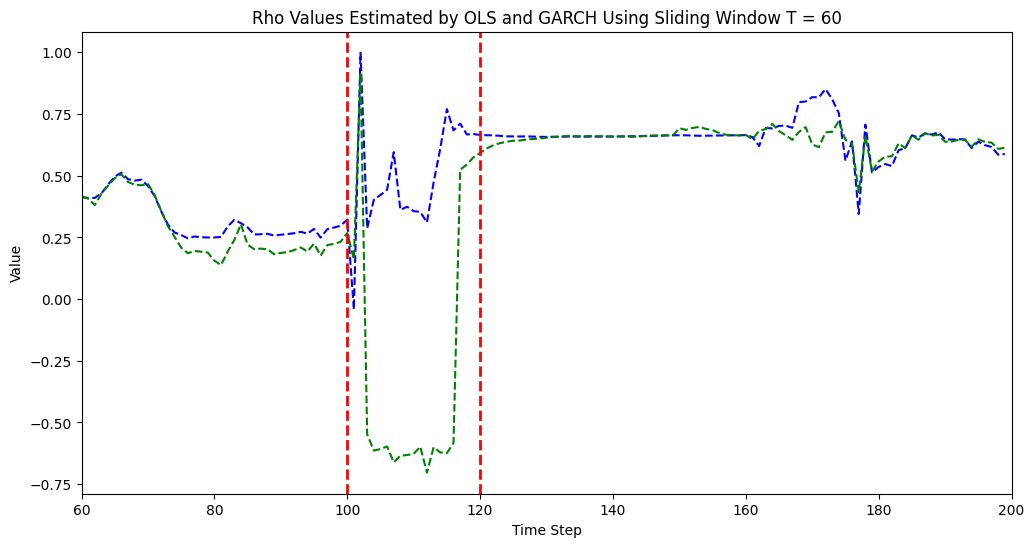

In [3]:
generator = create_ar1_generator(0.005, 0.5, 200)
rtns, _ = generator(lambda i: 0.5 if 100 < i < 120 else 0.02)
rtns_scaled = 100 * rtns

window_size, step_size = 60, 1
rolling_params = []
for i in range(window_size, len(rtns), step_size):
    X = rtns[i -window_size: i]
    y = rtns[i -window_size + 1: i + 1]

    X_with_const = sm.add_constant(X)
    OLS_model = OLS(y, X_with_const).fit()
    GARCH_model = arch_model(
        rtns_scaled[i - window_size: i + 1],
        mean='AR',
        lags=1,
        vol="GARCH",
        p=1,
        q=1
    ).fit(disp='off')

    rolling_params.append({
        'time': i,
        'OLS_rho': OLS_model.params[1],
        'GARCH_rho': GARCH_model.params.iloc[1],
    })

plt.figure(figsize=(12, 6))

times = [p['time'] for p in rolling_params]
OLS_rhos = [p['OLS_rho'] for p in rolling_params]
GARCH_rhos = [p['GARCH_rho'] for p in rolling_params]

plt.plot(times, OLS_rhos, '--b')
plt.plot(times, GARCH_rhos, '--g')
plt.axvline(x=100, color='red', linestyle='--', linewidth=2)
plt.axvline(x=120, color='red', linestyle='--', linewidth=2)
plt.xlim(times[0], len(rtns))
plt.title(f"Rho Values Estimated by OLS and GARCH Using Sliding Window T = {window_size}")
plt.ylabel('Value')
plt.xlabel('Time Step')

In [4]:
pro = ts.pro_api(os.getenv('TUSHARE_PRO_KEY'))
df = pro.fund_daily(
    ts_code='510300.SH',
    start_date='20150101',
    end_date='20260101',
    fields=[
        'ts_code',
        'trade_date',
        'pre_close',
        'open',
        'high',
        'low',
        'close',
        'change',
        'pct_chg',
        'vol',
        'amount'
    ]
)

df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.set_index('trade_date', drop=True)
df = df.sort_index()

feeds = DataFeeds(df, backtest_start='2020-01-01', backtest_end='2026-01-01')
state = StateManager.from_datafeeds(feeds)
broker = Broker.from_datafeeds(feeds)

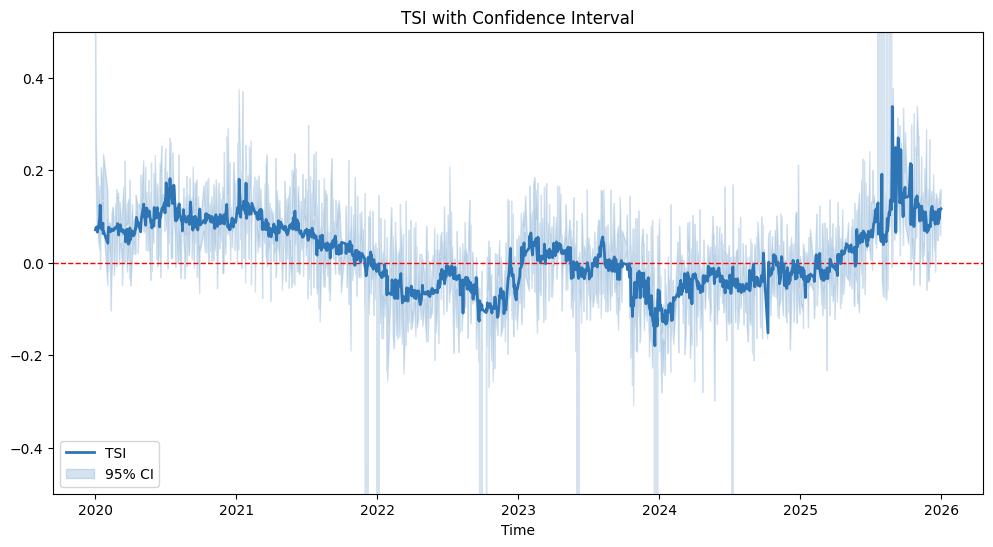

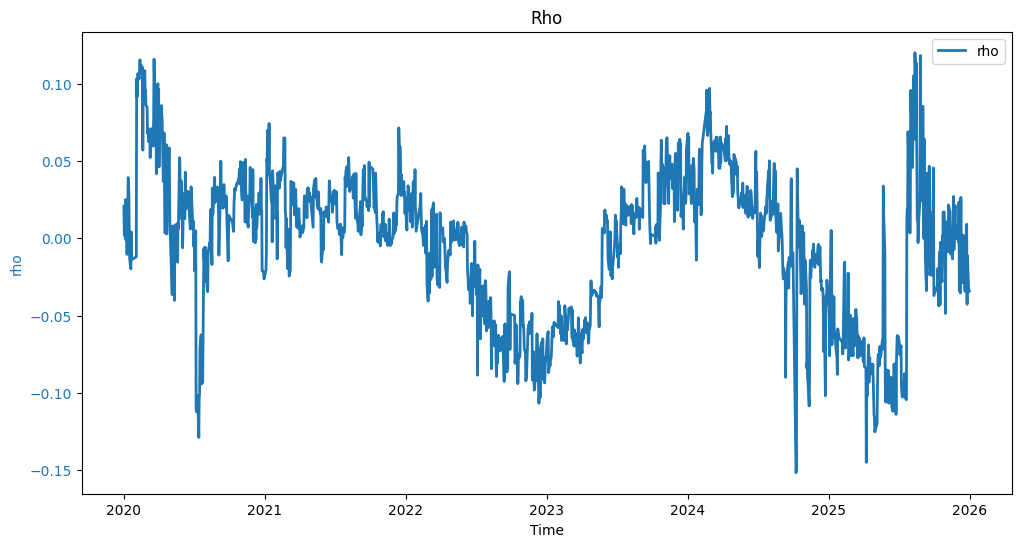

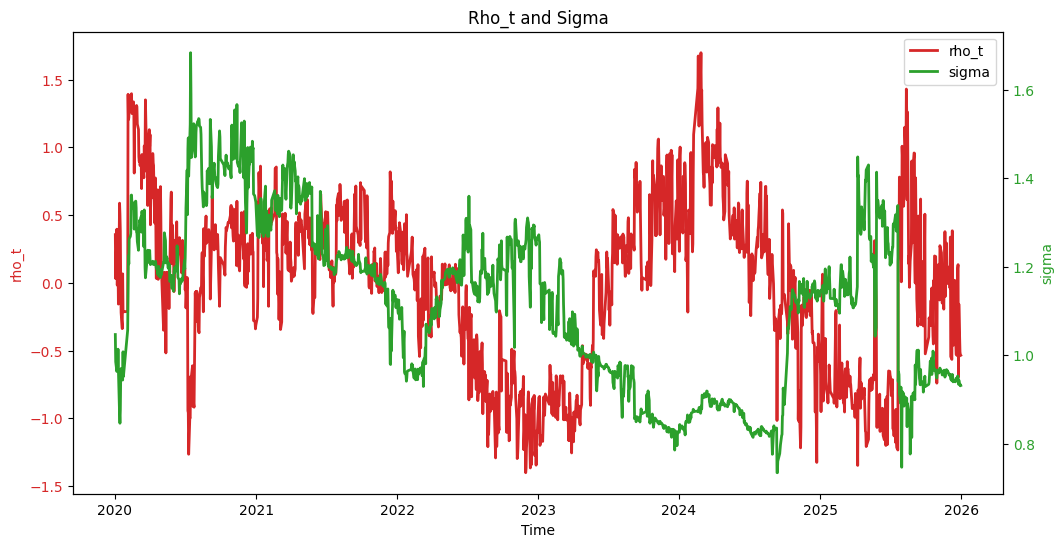

In [5]:
window_lower, window_upper = 21, 250
sma_lower, sma_upper = 5, 20
cache_path = DATA_DIR / 'cta_cache.csv'
use_cache = False

if cache_path.exists():
    state.load_from_csv(['tsi', 'tsi_ci_low', 'tsi_ci_high'], cache_path)
    use_cache = True

def calculate_kaufman_er(closes: pd.DataFrame):
    closes_lst = closes.tolist()
    direction = abs(closes_lst[-1] - closes_lst[0])
    volatility = closes.diff().abs().sum()
    er = direction / volatility

    return er

def calculate_rsi(closes, period=14):
    delta = closes.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi.iloc[-1]

def fit_ar_garch(rtns):
    rtns = rtns.copy()

    return arch_model(
        rtns,
        mean='AR',
        lags=1,
        vol='GARCH',
        p=1,
        q=1,
        rescale=True
    ).fit(disp="off")

def _bootstrap_single_iteration(result, nobs, seed):
    np.random.seed(seed)

    params = result.params.copy()

    simulated = result.model.simulate(
        params=params,
        nobs=nobs,
        burn=200
    )

    simulated_y = simulated['data']
    simulated_result = fit_ar_garch(simulated_y)

    const = simulated_result.params['Const']
    sigma_mean = simulated_result.conditional_volatility.mean()

    return const / sigma_mean

def bootstrap_tsi_ci(result, n_bootstrap=1000, n_jobs=-2):
    original_y = pd.Series(result.model.y).dropna()
    nobs = len(original_y)

    seeds = np.random.randint(0, 2**32-1, size=n_bootstrap)

    tsi_samples = Parallel(
        n_jobs=n_jobs,
        backend='multiprocessing',
        verbose=10
    )(
        delayed(_bootstrap_single_iteration)(result, nobs, seed)
        for seed in seeds
    )

    tsi_samples = np.array(tsi_samples)
    tsi_samples = tsi_samples[np.isfinite(tsi_samples)]

    return np.percentile(tsi_samples, 2.5), np.percentile(tsi_samples, 97.5)

def estimate_parameters(rtns: pd.DataFrame, use_cache):
    result = fit_ar_garch(rtns)

    const = result.params['Const']
    rho = result.params['pct_chg[1]']
    sigma_mean = result.conditional_volatility.mean()
    rho_t = result.tvalues['pct_chg[1]']

    tsi = const / sigma_mean
    if not use_cache:
        tsi_ci_low, tsi_ci_high = bootstrap_tsi_ci(result)
    else:
        tsi_ci_low, tsi_ci_high = 0, 0

    return tsi, tsi_ci_low, tsi_ci_high, rho, rho_t, sigma_mean

buy_long_date = None
state['trade'] = None

while feeds.next():
    closed_df = feeds.get_last(30, 'day')['close']
    er = calculate_kaufman_er(closed_df)
    adaptive_window = int(window_upper - er * (window_upper - window_lower))
    state['er'] = er
    state['window'] = adaptive_window

    rtns = feeds.get_last(adaptive_window, 'day')['pct_chg']

    tsi, tsi_ci_low, tsi_ci_high, rho, rho_t, sigma_mean = estimate_parameters(rtns, use_cache)

    state['tsi'] = tsi

    if not use_cache:
        state['tsi_ci_low'] = tsi_ci_low
        state['tsi_ci_high'] = tsi_ci_high

    state['rho'] = rho
    state['rho_t'] = rho_t
    state['sigma_mean'] = sigma_mean

    tsi_history = state.get('tsi', end_date=feeds.cur_date)
    sigma_history = state.get('sigma_mean')
    cond1 = abs(tsi) > tsi_history.abs().median() or tsi_ci_high < 0 or tsi_ci_low > 0
    cond2 = rho > 0.01
    cond3 = rho_t > 1.5 or sigma_mean < sigma_history.quantile(0.95)
    state['cond'] = cond1 or (cond2 and cond3)

    cond_history = state.get_last_n_day(10, 'cond')
    if cond_history is not None and len(cond_history) == 10 and cond_history.all():
        if tsi > 0:
            state['market_regime'] = 'trend_up'
        else:
            state['market_regime'] = 'trend_down'
    else:
        state['market_regime'] = 'sideways'

    trade_data = state.get_last_n_day(1, 'trade')
    if not trade_data.empty:
        state['trade'] = trade_data.iloc[0]
    else:
        state['trade'] = None

    cur_open = feeds.get_last(1, 'day', include_current=True)['open'].values[0]

    closes = feeds.get_last(15, 'day')['close']
    rsi = calculate_rsi(closes)

    # 入场信号
    if not broker.portfolio.holdings:
        # 趋势市
        if state['market_regime'] == 'trend_up':
            pass
            sma_window = int(sma_upper - er * (sma_upper - sma_lower))
            sma = feeds.get_last(sma_window, 'day')['close'].mean()

            if cur_open > sma:
                broker.buy('510300.SH', at='open')
                state['trade'] = 'long by trend'
                buy_long_date = feeds.cur_date

        elif state['market_regime'] == 'trend_down':
            pass

        # 震荡市
        else:
            if rsi <= 30:
                broker.buy('510300.SH', at='close')
                state['trade'] = 'long by sideways'
    # 离场信号
    else:
        if state['trade'] == 'long by trend':
            atr = state.get_last_n_day(14, 'tr').mean()
            highest = feeds.get('high', buy_long_date, feeds.cur_date - pd.Timedelta(days=1)).max()
            if cur_open < highest - 4.5 * atr or state['market_regime'] == 'sideways':
                broker.sell('510300.SH')
                state['trade'] = None
                buy_long_date = None

        elif state['trade'] == 'long by sideways':
            if rsi >= 40 or state['market_regime'] != 'sideways':
                broker.sell('510300.SH', at='close')
                state['trade'] = None

    # 当日交易结束后进行计算，使用当日数据
    df = feeds.get_last(2, 'day', include_current=True)
    high_t = df['high'].iloc[-1]
    low_t = df['low'].iloc[-1]
    close_t_1 = df['close'].iloc[0]
    tr = max(abs(high_t - low_t), abs(high_t - close_t_1), abs(low_t - close_t_1))
    state['tr'] = tr

ers = state.get('er')
windows = state.get('window')

tsi = state.get('tsi')
ci_low, ci_high = state.get('tsi_ci_low'), state.get('tsi_ci_high')
rho, rho_t = state.get('rho'), state.get('rho_t')
sigma = state.get('sigma_mean')

tsi_data = pd.concat([tsi, ci_low, ci_high], axis=1)

if not cache_path.exists():
    tsi_data.to_csv(cache_path, index=True)

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_title('TSI with Confidence Interval')
ax1.set_xlabel('Time')
ax1.plot(tsi, color='#2E75B6', linewidth=2, label='TSI', zorder=3)
ax1.fill_between(
    tsi.index,
    ci_low,
    ci_high,
    alpha=0.2,
    color='#2E75B6',
    label='95% CI',
    zorder=1
)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, zorder=2)
ax1.set_ylim(-0.5, 0.5)
ax1.legend(loc='best')

fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.set_title('Rho')
ax2.set_xlabel('Time')
ax2.set_ylabel('rho', color='#1f77b4')
ax2.plot(rho, color='#1f77b4', linestyle='-', linewidth=2, label='rho')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.legend(loc='best')

fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.set_title('Rho_t and Sigma')
ax3.set_xlabel('Time')

ax3.set_ylabel('rho_t', color='#d62728')
ax3.plot(rho_t, color='#d62728', linestyle='-', linewidth=2, label='rho_t')
ax3.tick_params(axis='y', labelcolor='#d62728')

ax4 = ax3.twinx()
ax4.set_ylabel('sigma', color='#2ca02c')
ax4.plot(sigma, color='#2ca02c', linestyle='-', linewidth=2, label='sigma')
ax4.tick_params(axis='y', labelcolor='#2ca02c')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax4.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()

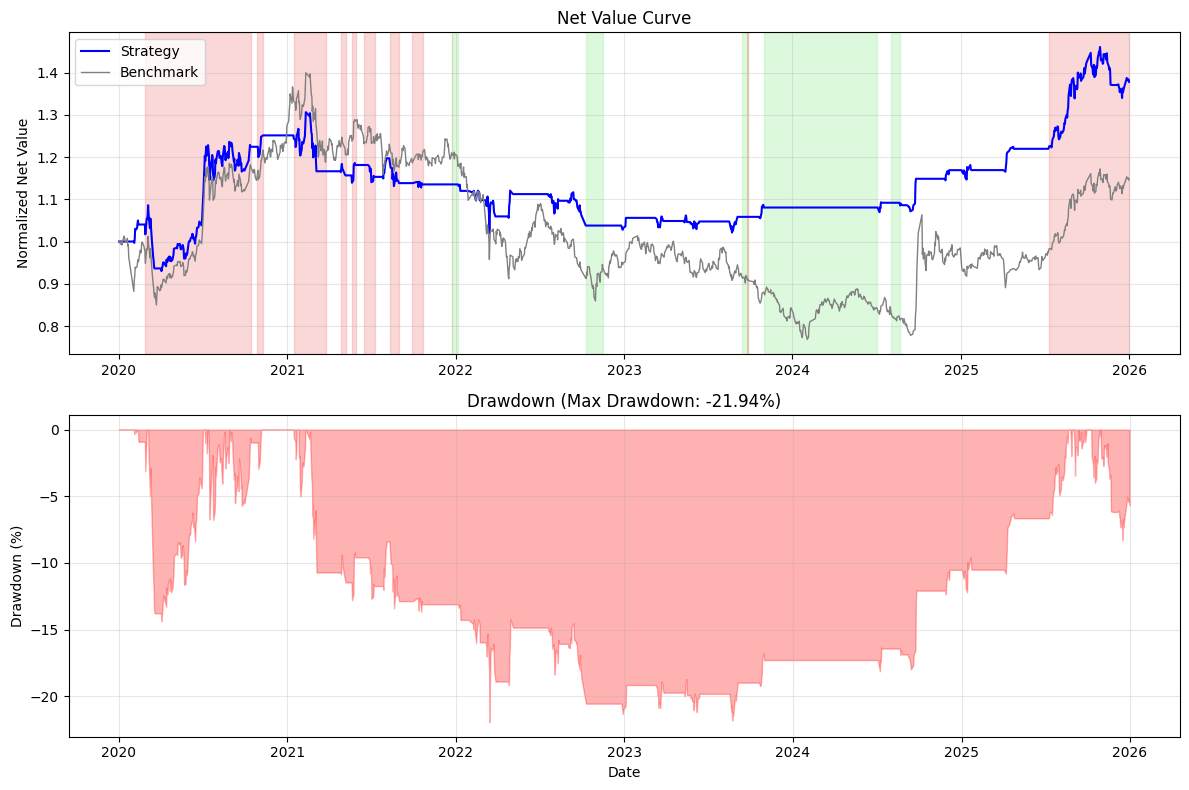

In [6]:
broker.analyse_performance()
nav = broker.performance['nav']

nav_norm = nav / nav.iloc[0]
rolling_max = nav_norm.cummax()
drawdown = (nav_norm - rolling_max) / rolling_max
max_dd = drawdown.min()

regime_series = state.get('market_regime')
regime_series = regime_series.reindex(nav.index).ffill()

def get_regime_spans(series):
    spans = []
    if series.empty:
        return spans

    start = series.index[0]
    prev_regime = series.iloc[0]

    for idx, regime in series.items():
        if regime != prev_regime:
            spans.append((start, idx, prev_regime))
            start = idx
            prev_regime = regime

    spans.append((start, series.index[-1], prev_regime))
    return spans

regime_spans = get_regime_spans(regime_series)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(nav_norm.index, nav_norm.values, color='blue', linewidth=1.5, label='Strategy')
ax1.plot(
    feeds.get('close') / feeds.get('close')[0],
    color='gray', linewidth=1, label='Benchmark'
)

for start, end, regime in regime_spans:
    if regime == 'trend_up':
        ax1.axvspan(start, end + pd.Timedelta(days=1), color='lightcoral', alpha=0.3)
    elif regime == 'trend_down':
        ax1.axvspan(start, end + pd.Timedelta(days=1), color='lightgreen', alpha=0.3)

ax1.set_title('Net Value Curve')
ax1.set_ylabel('Normalized Net Value')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.fill_between(drawdown.index, drawdown.values * 100, 0,
                 color='red', alpha=0.3)
ax2.set_title(f'Drawdown (Max Drawdown: {max_dd:.2%})')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()